# Elliptic Bitcoin Dataset — Exploratory Data Analysis

The Elliptic dataset is a graph of Bitcoin transactions where:
- **Nodes** are transactions (203,769 total)
- **Edges** are directed Bitcoin flows between transactions (234,355 total)
- **Labels**: class 1 = illicit, class 2 = licit, class 3 = unknown (unlabeled)

Each node has 166 features: 1 time step, 93 local transaction features, and 72 aggregated neighborhood features.

In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path to your project folder
# Note: Google Drive mounts to '/content/drive/MyDrive' by default
project_path = '/content/drive/MyDrive/stat175-final-project/'

# 3. Change the current working directory
if os.path.exists(project_path):
    %cd {project_path}
    print(f"\nSuccess! Working directory set to: {os.getcwd()}")
else:
    print(f"\nError: The directory '{project_path}' was not found. Please check the spelling.")

# 4. Install dependencies from requirements.txt
if os.path.exists('requirements.txt'):
    !pip install -r requirements.txt
else:
    print("\n'requirements.txt' not found in the current directory.")

Mounted at /content/drive
/content/drive/MyDrive/stat175-final-project

Success! Working directory set to: /content/drive/MyDrive/stat175-final-project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.7 MB/s eta 0:00:00


In [7]:
%cd /content/drive/MyDrive/stat175-final-project/

/content/drive/MyDrive/stat175-final-project


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA = './data/'
classes_df  = pd.read_csv(DATA + 'txs_classes.csv')
edges_df    = pd.read_csv(DATA + 'txs_edgelist.csv')
features_df = pd.read_csv(DATA + 'txs_features.csv')

print('classes shape :', classes_df.shape)
print('edges shape   :', edges_df.shape)
print('features shape:', features_df.shape)

classes shape : (203769, 2)
edges shape   : (234355, 2)
features shape: (203769, 184)


## 1. Class Distribution

In [10]:
label_map = {1: 'Illicit', 2: 'Licit', 3: 'Unknown'}
class_counts = classes_df['class'].value_counts().sort_index()
class_counts.index = [label_map[i] for i in class_counts.index]

print('Class counts:')
print(class_counts.to_string())
print()
print('Proportions:')
print((class_counts / class_counts.sum()).round(4).to_string())

labeled = classes_df[classes_df['class'].isin([1, 2])]
illicit = (labeled['class'] == 1).sum()
licit   = (labeled['class'] == 2).sum()
print(f'\nAmong LABELED nodes only:')
print(f'  Illicit: {illicit:,}  ({illicit/(illicit+licit)*100:.1f}%)')
print(f'  Licit  : {licit:,}  ({licit/(illicit+licit)*100:.1f}%)')
print(f'  Imbalance ratio (licit:illicit): {licit/illicit:.1f}:1')

Class counts:
Illicit      4545
Licit       42019
Unknown    157205

Proportions:
Illicit    0.0223
Licit      0.2062
Unknown    0.7715

Among LABELED nodes only:
  Illicit: 4,545  (9.8%)
  Licit  : 42,019  (90.2%)
  Imbalance ratio (licit:illicit): 9.2:1


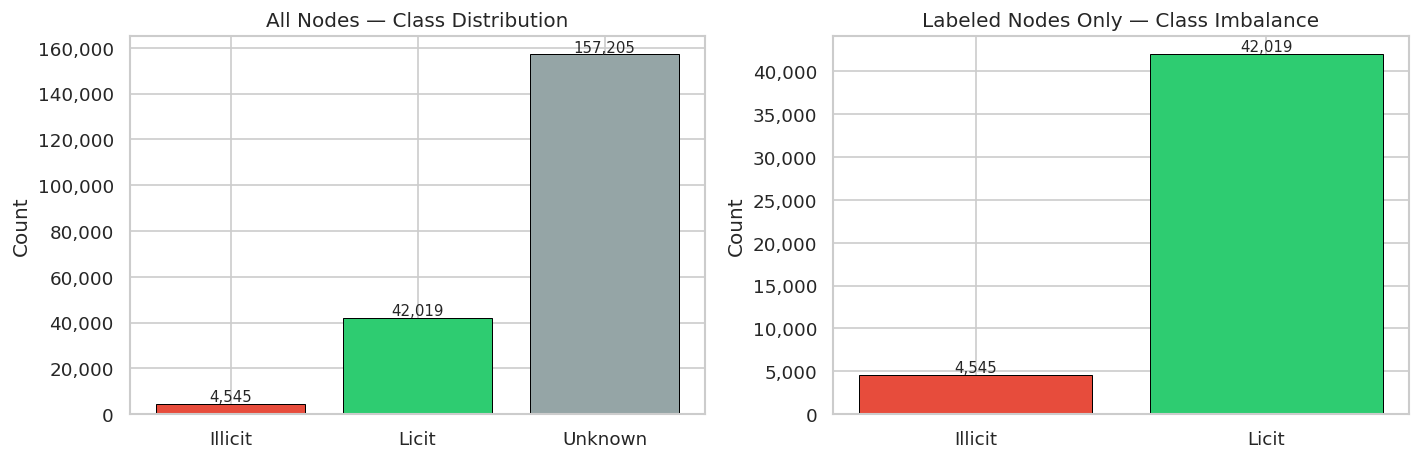

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#2ecc71', '#95a5a6']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('All Nodes — Class Distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontsize=9)

labeled_counts = pd.Series({'Illicit': illicit, 'Licit': licit})
axes[1].bar(labeled_counts.index, labeled_counts.values, color=['#e74c3c', '#2ecc71'],
            edgecolor='black', linewidth=0.6)
axes[1].set_title('Labeled Nodes Only — Class Imbalance')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(axes[1].patches, labeled_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Temporal Distribution — Time Steps

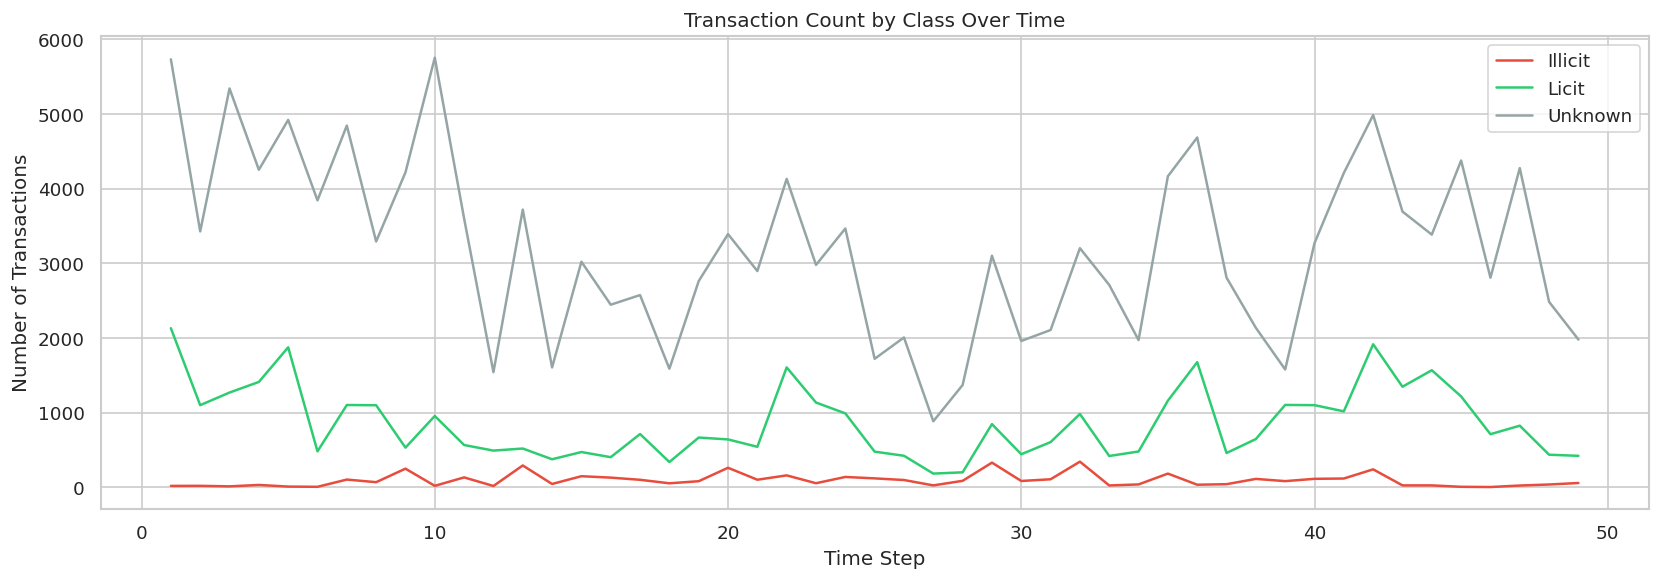

Number of distinct time steps: 49
Time step range: 1 – 49


In [12]:
df = features_df[['txId', 'Time step']].merge(classes_df, on='txId')
df['label'] = df['class'].map(label_map)

time_class = df.groupby(['Time step', 'label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(['Illicit', 'Licit', 'Unknown'], ['#e74c3c', '#2ecc71', '#95a5a6']):
    if col in time_class.columns:
        ax.plot(time_class.index, time_class[col], label=col, color=color, linewidth=1.5)

ax.set_xlabel('Time Step')
ax.set_ylabel('Number of Transactions')
ax.set_title('Transaction Count by Class Over Time')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Number of distinct time steps: {features_df["Time step"].nunique()}')
print(f'Time step range: {features_df["Time step"].min()} – {features_df["Time step"].max()}')

/tmp/ipykernel_4355/3288084292.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  illicit_frac = labeled_time.groupby('Time step').apply(


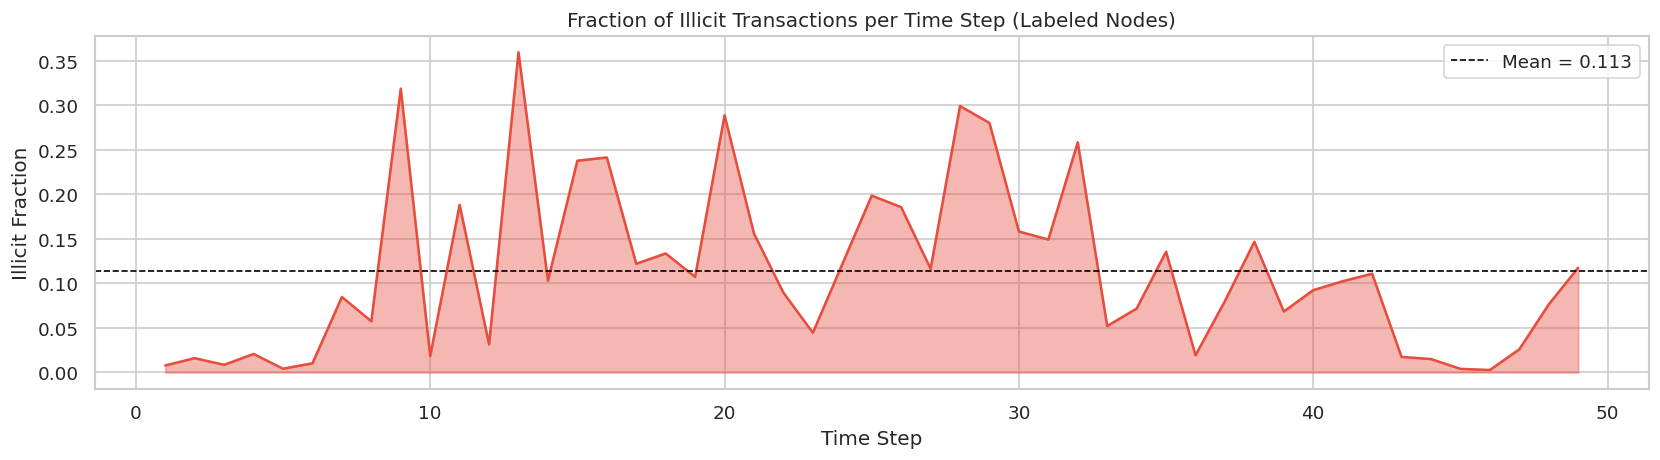

In [13]:
# Illicit fraction per time step (labeled only)
labeled_time = df[df['class'].isin([1, 2])].copy()
illicit_frac = labeled_time.groupby('Time step').apply(
    lambda g: (g['class'] == 1).sum() / len(g)
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(illicit_frac.index, illicit_frac.values, alpha=0.4, color='#e74c3c')
ax.plot(illicit_frac.index, illicit_frac.values, color='#e74c3c', linewidth=1.5)
ax.axhline(illicit_frac.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean = {illicit_frac.mean():.3f}')
ax.set_xlabel('Time Step')
ax.set_ylabel('Illicit Fraction')
ax.set_title('Fraction of Illicit Transactions per Time Step (Labeled Nodes)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Missing Data Analysis

In [14]:
print('=== Missing Values in features_df ===')
feat_missing = features_df.isnull().sum()
print(f'Columns with any missing value: {(feat_missing > 0).sum()} / {len(feat_missing)}')
if feat_missing.max() > 0:
    print(feat_missing[feat_missing > 0])
else:
    print('No missing values in features_df.')

print('\n=== Missing Values in classes_df ===')
cls_missing = classes_df.isnull().sum()
print(cls_missing)

print('\n=== Missing Values in edges_df ===')
edge_missing = edges_df.isnull().sum()
print(edge_missing)

# Check for nodes in edgelist not in features
edge_nodes = set(edges_df['txId1']).union(set(edges_df['txId2']))
feature_nodes = set(features_df['txId'])
class_nodes = set(classes_df['txId'])

print(f'\n=== Node Coverage ===')
print(f'Unique nodes in edgelist  : {len(edge_nodes):,}')
print(f'Unique nodes in features  : {len(feature_nodes):,}')
print(f'Unique nodes in classes   : {len(class_nodes):,}')
print(f'Edge nodes missing from features: {len(edge_nodes - feature_nodes):,}')
print(f'Feature nodes missing from classes: {len(feature_nodes - class_nodes):,}')

=== Missing Values in features_df ===
Columns with any missing value: 17 / 184
in_txs_degree           965
out_txs_degree          965
total_BTC               965
fees                    965
size                    965
num_input_addresses     965
num_output_addresses    965
in_BTC_min              965
in_BTC_max              965
in_BTC_mean             965
in_BTC_median           965
in_BTC_total            965
out_BTC_min             965
out_BTC_max             965
out_BTC_mean            965
out_BTC_median          965
out_BTC_total           965
dtype: int64

=== Missing Values in classes_df ===
txId     0
class    0
dtype: int64

=== Missing Values in edges_df ===
txId1    0
txId2    0
dtype: int64

=== Node Coverage ===
Unique nodes in edgelist  : 203,769
Unique nodes in features  : 203,769
Unique nodes in classes   : 203,769
Edge nodes missing from features: 0
Feature nodes missing from classes: 0


## 4. Node (Transaction) Feature Statistics

In [15]:
# Feature groups
local_feats = [c for c in features_df.columns if c.startswith('Local_feature')]
agg_feats   = [c for c in features_df.columns if c.startswith('Aggregate_feature')]
# Named tail features (Bitcoin-specific)
named_feats = [c for c in features_df.columns
               if c not in local_feats and c not in agg_feats
               and c not in ['txId', 'Time step']]

print(f'Local features    : {len(local_feats)}')
print(f'Aggregate features: {len(agg_feats)}')
print(f'Named features    : {len(named_feats)}')
print(f'Named feature list: {named_feats}')

Local features    : 93
Aggregate features: 72
Named features    : 17
Named feature list: ['in_txs_degree', 'out_txs_degree', 'total_BTC', 'fees', 'size', 'num_input_addresses', 'num_output_addresses', 'in_BTC_min', 'in_BTC_max', 'in_BTC_mean', 'in_BTC_median', 'in_BTC_total', 'out_BTC_min', 'out_BTC_max', 'out_BTC_mean', 'out_BTC_median', 'out_BTC_total']


In [16]:
# Summary stats for named (interpretable) features split by class
merged = features_df.merge(classes_df, on='txId')
labeled_merged = merged[merged['class'].isin([1, 2])].copy()
labeled_merged['label'] = labeled_merged['class'].map({1: 'Illicit', 2: 'Licit'})

print('Summary stats for named features (labeled nodes):')
labeled_merged.groupby('label')[named_feats].median().T.round(4)

Summary stats for named features (labeled nodes):


label,Illicit,Licit
in_txs_degree,1.0000,1.0000
out_txs_degree,1.0000,1.0000
total_BTC,0.1234,0.4818
fees,0.0002,0.0004
size,192.0000,372.0000
num_input_addresses,1.0000,2.0000
num_output_addresses,1.0000,2.0000
in_BTC_min,0.0982,0.0327
in_BTC_max,0.1150,0.3710
in_BTC_mean,0.1074,0.2027


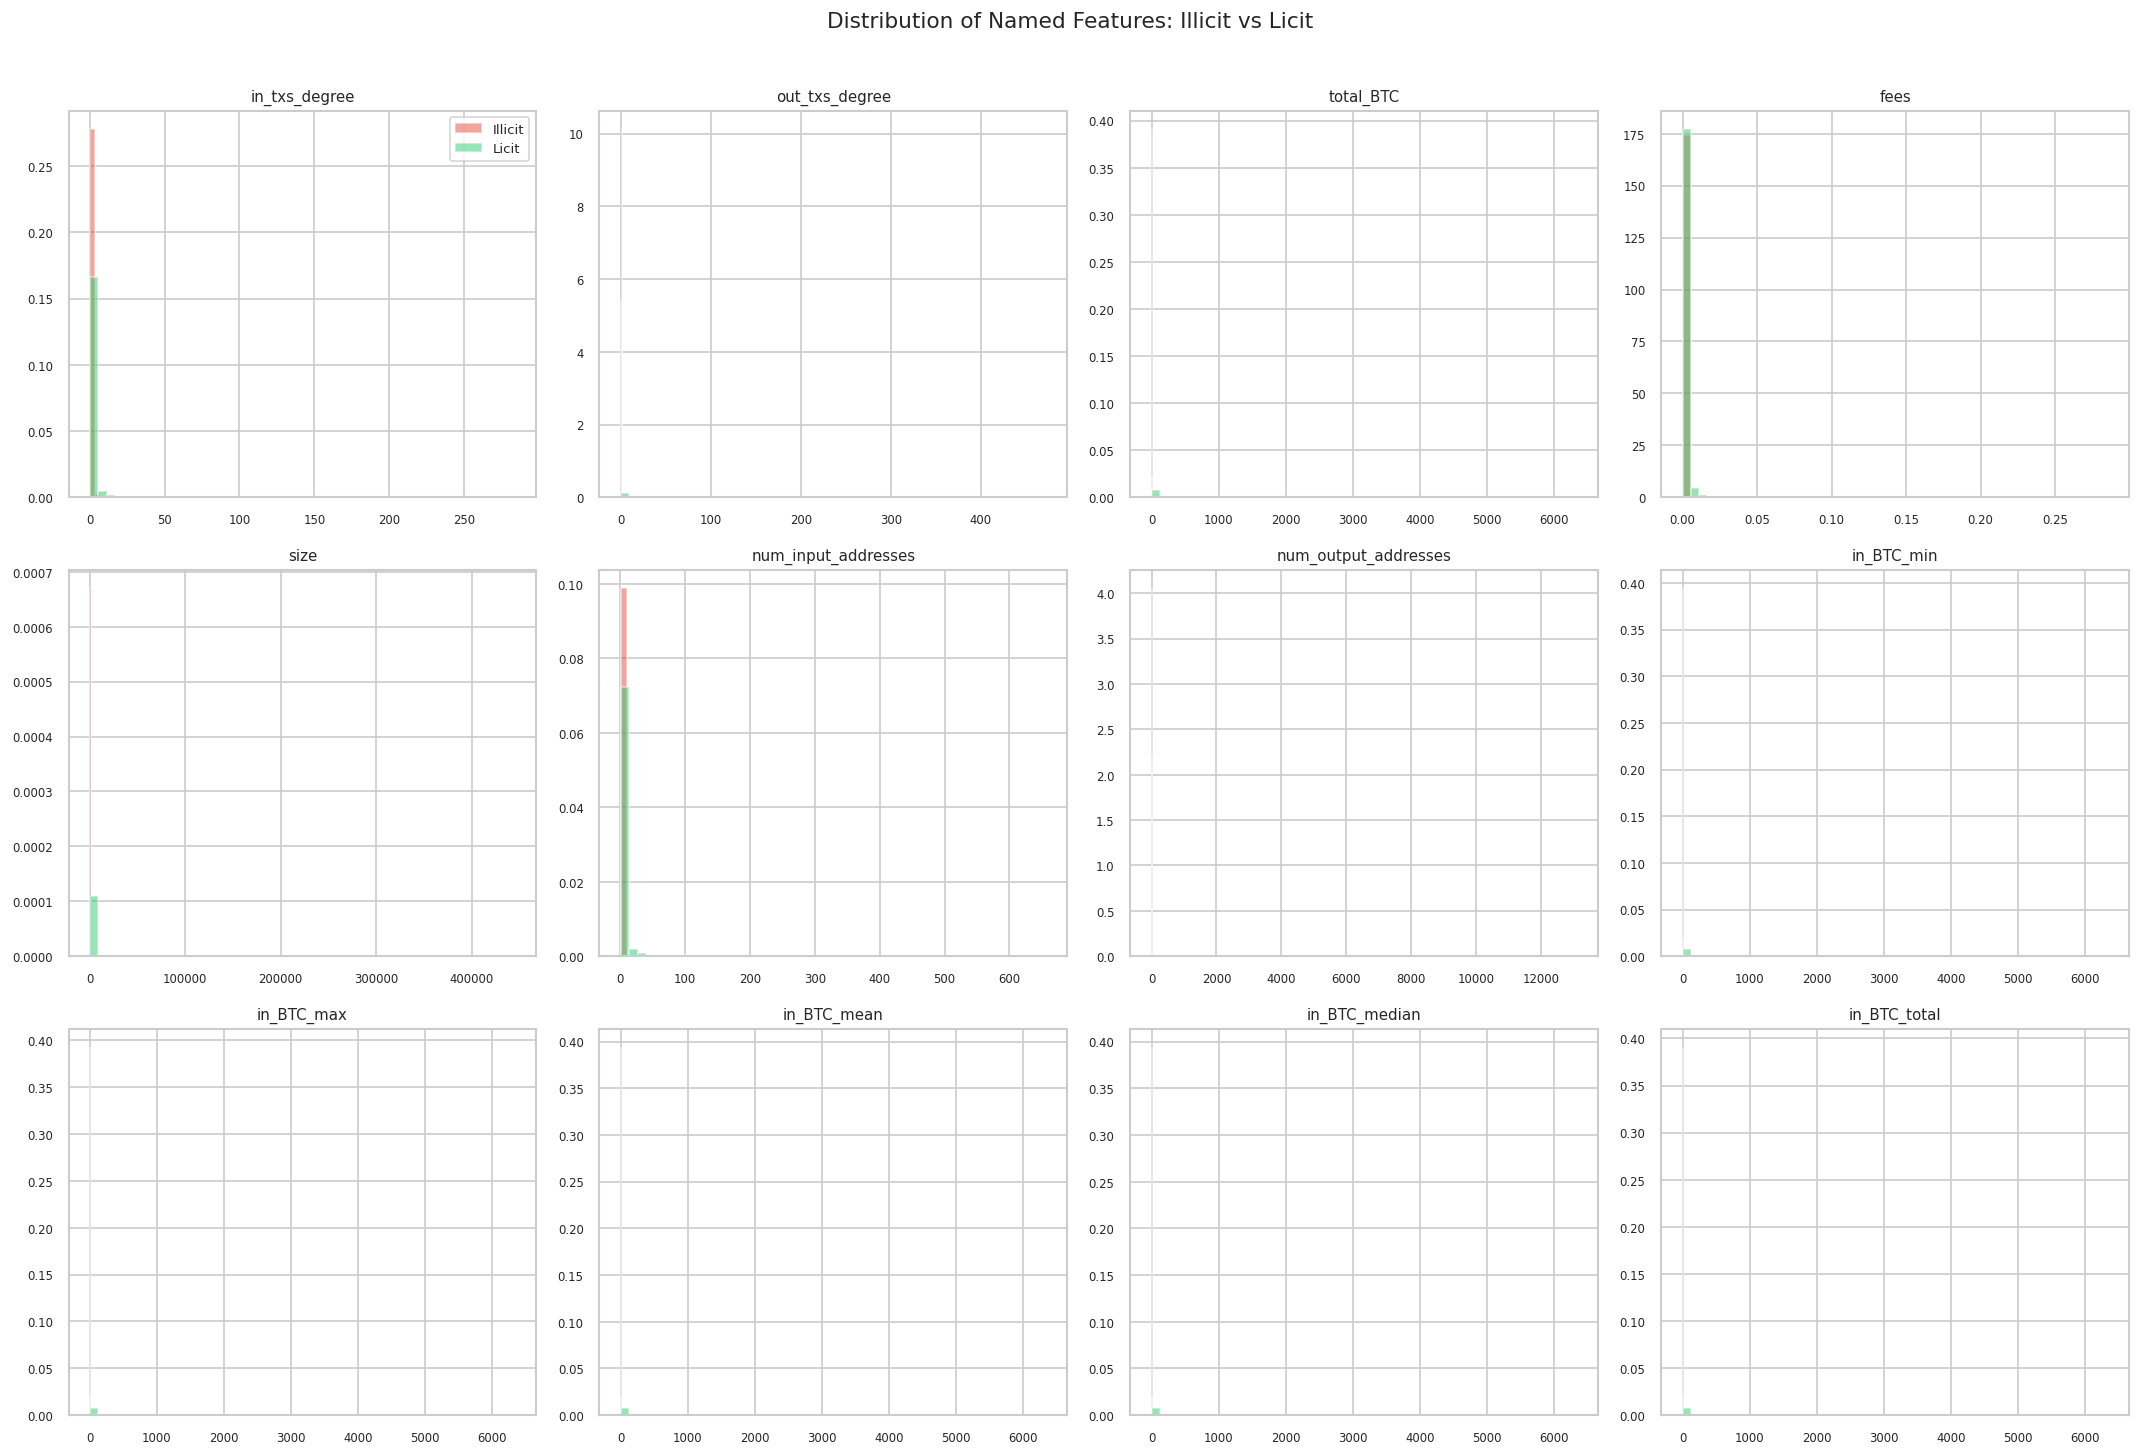

In [17]:
# Distribution of named features by class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(named_feats[:12]):
    for label, color in [('Illicit', '#e74c3c'), ('Licit', '#2ecc71')]:
        data = labeled_merged[labeled_merged['label'] == label][feat].dropna()
        axes[i].hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=8)

for j in range(len(named_feats[:12]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Named Features: Illicit vs Licit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# Feature variance across all nodes — are some features near-constant?
feat_cols = local_feats + agg_feats + named_feats
variances = features_df[feat_cols].var().sort_values()

print(f'Features with near-zero variance (<1e-6): {(variances < 1e-6).sum()}')
print(f'\nLowest variance features:')
print(variances.head(10).to_string())
print(f'\nHighest variance features:')
print(variances.tail(10).to_string())

Features with near-zero variance (<1e-6): 0

Lowest variance features:
fees                    0.000015
Aggregate_feature_33    1.000005
Local_feature_42        1.000005
Local_feature_50        1.000005
Local_feature_5         1.000005
Local_feature_24        1.000005
Local_feature_12        1.000005
Aggregate_feature_5     1.000005
Local_feature_15        1.000005
Local_feature_7         1.000005

Highest variance features:
out_BTC_mean     4.503923e+03
out_BTC_max      2.388977e+04
in_BTC_min       2.412182e+04
in_BTC_median    2.417330e+04
in_BTC_mean      2.417567e+04
in_BTC_max       2.481223e+04
out_BTC_total    2.525113e+04
total_BTC        2.525113e+04
in_BTC_total     2.525116e+04
size             7.852999e+06


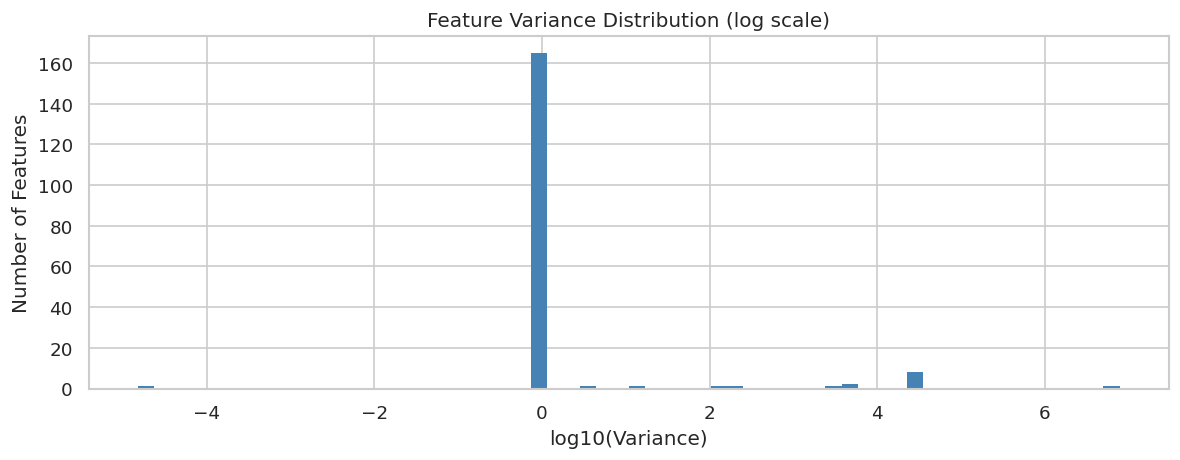

In [19]:
# Variance distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(variances.values + 1e-10), bins=60, color='steelblue', edgecolor='none')
ax.set_xlabel('log10(Variance)')
ax.set_ylabel('Number of Features')
ax.set_title('Feature Variance Distribution (log scale)')
plt.tight_layout()
plt.show()

## 5. Edge / Graph Structure Statistics

In [20]:
# Degree distribution
out_degree = edges_df.groupby('txId1').size().rename('out_degree')
in_degree  = edges_df.groupby('txId2').size().rename('in_degree')

all_ids = pd.Series(list(feature_nodes), name='txId')
degree_df = all_ids.to_frame().join(out_degree, on='txId').join(in_degree, on='txId').fillna(0)
degree_df['total_degree'] = degree_df['out_degree'] + degree_df['in_degree']

print('=== Degree Statistics (all nodes) ===')
print(degree_df[['in_degree', 'out_degree', 'total_degree']].describe().round(2).to_string())
print(f'\nNodes with zero in-degree (sources): {(degree_df["in_degree"] == 0).sum():,}')
print(f'Nodes with zero out-degree (sinks) : {(degree_df["out_degree"] == 0).sum():,}')
print(f'Isolated nodes (degree=0)          : {(degree_df["total_degree"] == 0).sum():,}')

=== Degree Statistics (all nodes) ===
       in_degree  out_degree  total_degree
count  203769.00   203769.00     203769.00
mean        1.15        1.15          2.30
std         3.91        1.89          4.33
min         0.00        0.00          1.00
25%         0.00        1.00          1.00
50%         1.00        1.00          2.00
75%         1.00        1.00          2.00
max       284.00      472.00        473.00

Nodes with zero in-degree (sources): 55,322
Nodes with zero out-degree (sinks) : 37,424
Isolated nodes (degree=0)          : 0


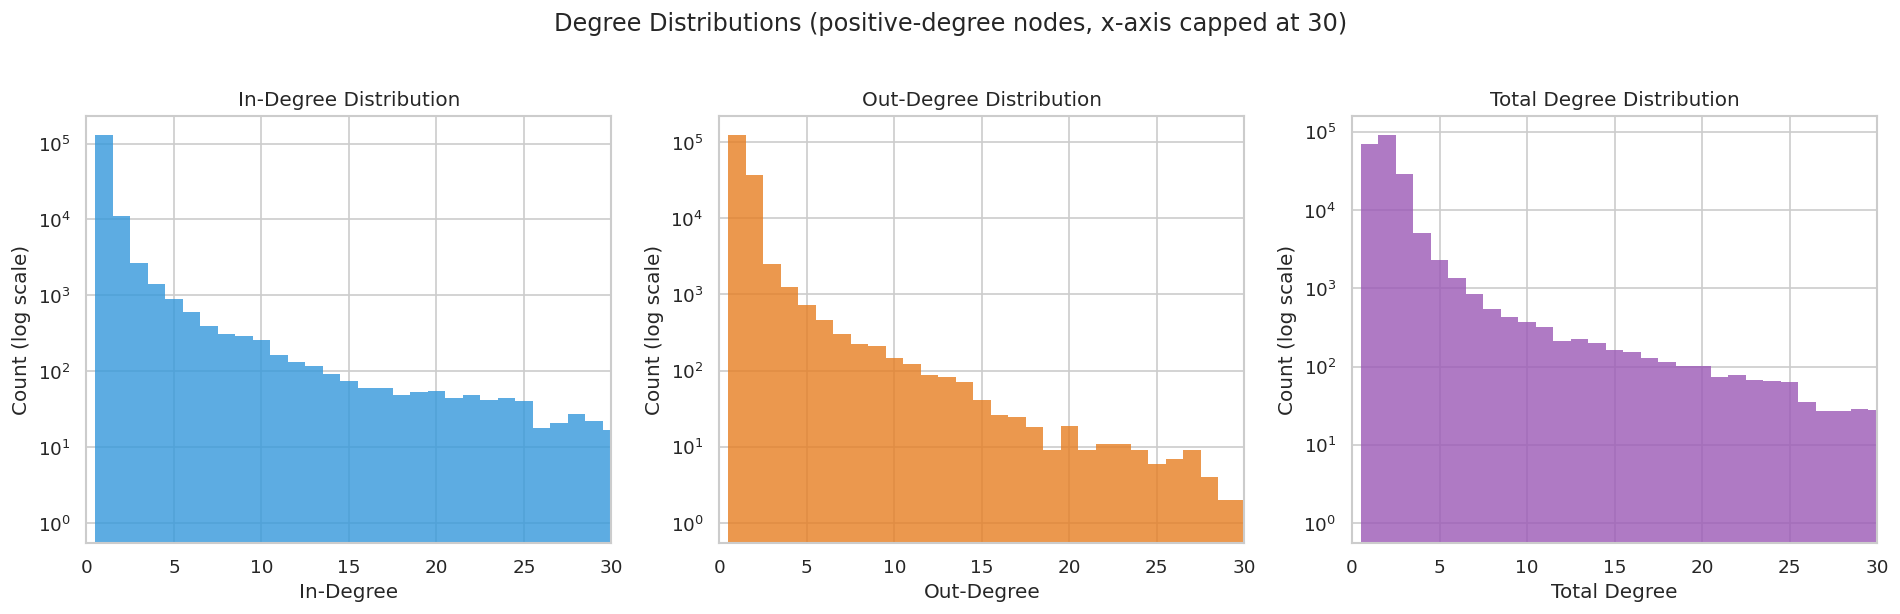

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, color in zip(
    axes,
    ['in_degree', 'out_degree', 'total_degree'],
    ['In-Degree', 'Out-Degree', 'Total Degree'],
    ['#3498db', '#e67e22', '#9b59b6']
):
    vals = degree_df[col][degree_df[col] > 0]
    ax.hist(vals, bins=np.arange(0.5, vals.max()+1.5, 1), color=color, edgecolor='none', alpha=0.8)
    ax.set_yscale('log')
    ax.set_xlabel(title)
    ax.set_ylabel('Count (log scale)')
    ax.set_title(f'{title} Distribution')
    ax.set_xlim(0, min(30, vals.max()))

plt.suptitle('Degree Distributions (positive-degree nodes, x-axis capped at 30)', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Degree by class
degree_class = degree_df.merge(classes_df, on='txId')
degree_class['label'] = degree_class['class'].map(label_map)

print('=== Mean Degree by Class ===')
print(degree_class.groupby('label')[['in_degree', 'out_degree', 'total_degree']].mean().round(3).to_string())

=== Mean Degree by Class ===
         in_degree  out_degree  total_degree
label                                       
Illicit      1.270       0.742         2.012
Licit        1.909       1.186         3.095
Unknown      0.944       1.152         2.096


In [23]:
# Self-loops and duplicate edges
self_loops = (edges_df['txId1'] == edges_df['txId2']).sum()
dup_edges  = edges_df.duplicated().sum()
print(f'Self-loops    : {self_loops}')
print(f'Duplicate edges: {dup_edges}')
print(f'Total edges   : {len(edges_df):,}')
print(f'Unique edges  : {edges_df.drop_duplicates().shape[0]:,}')

# Edge label coverage — what fraction of edges connect labeled nodes?
labeled_ids = set(labeled['txId'])
both_labeled = edges_df[edges_df['txId1'].isin(labeled_ids) & edges_df['txId2'].isin(labeled_ids)]
print(f'\nEdges where BOTH endpoints are labeled: {len(both_labeled):,} / {len(edges_df):,} ({len(both_labeled)/len(edges_df)*100:.1f}%)')

Self-loops    : 0
Duplicate edges: 0
Total edges   : 234,355
Unique edges  : 234,355

Edges where BOTH endpoints are labeled: 36,624 / 234,355 (15.6%)


## 6. Feature Correlation Overview

In [24]:
# Correlation of named features with label (point-biserial, labeled nodes only)
from scipy import stats

binary_label = labeled_merged['class'].map({1: 1, 2: 0})

correlations = {}
for feat in named_feats:
    r, p = stats.pointbiserialr(binary_label, labeled_merged[feat])
    correlations[feat] = (r, p)

corr_df = pd.DataFrame(correlations, index=['r', 'p']).T.sort_values('r', key=abs, ascending=False)
print('Correlation of named features with illicit label (1=illicit, 0=licit):')
print(corr_df.round(4).to_string())

Correlation of named features with illicit label (1=illicit, 0=licit):
                       r   p
in_txs_degree        NaN NaN
out_txs_degree       NaN NaN
total_BTC            NaN NaN
fees                 NaN NaN
size                 NaN NaN
num_input_addresses  NaN NaN
num_output_addresses NaN NaN
in_BTC_min           NaN NaN
in_BTC_max           NaN NaN
in_BTC_mean          NaN NaN
in_BTC_median        NaN NaN
in_BTC_total         NaN NaN
out_BTC_min          NaN NaN
out_BTC_max          NaN NaN
out_BTC_mean         NaN NaN
out_BTC_median       NaN NaN
out_BTC_total        NaN NaN


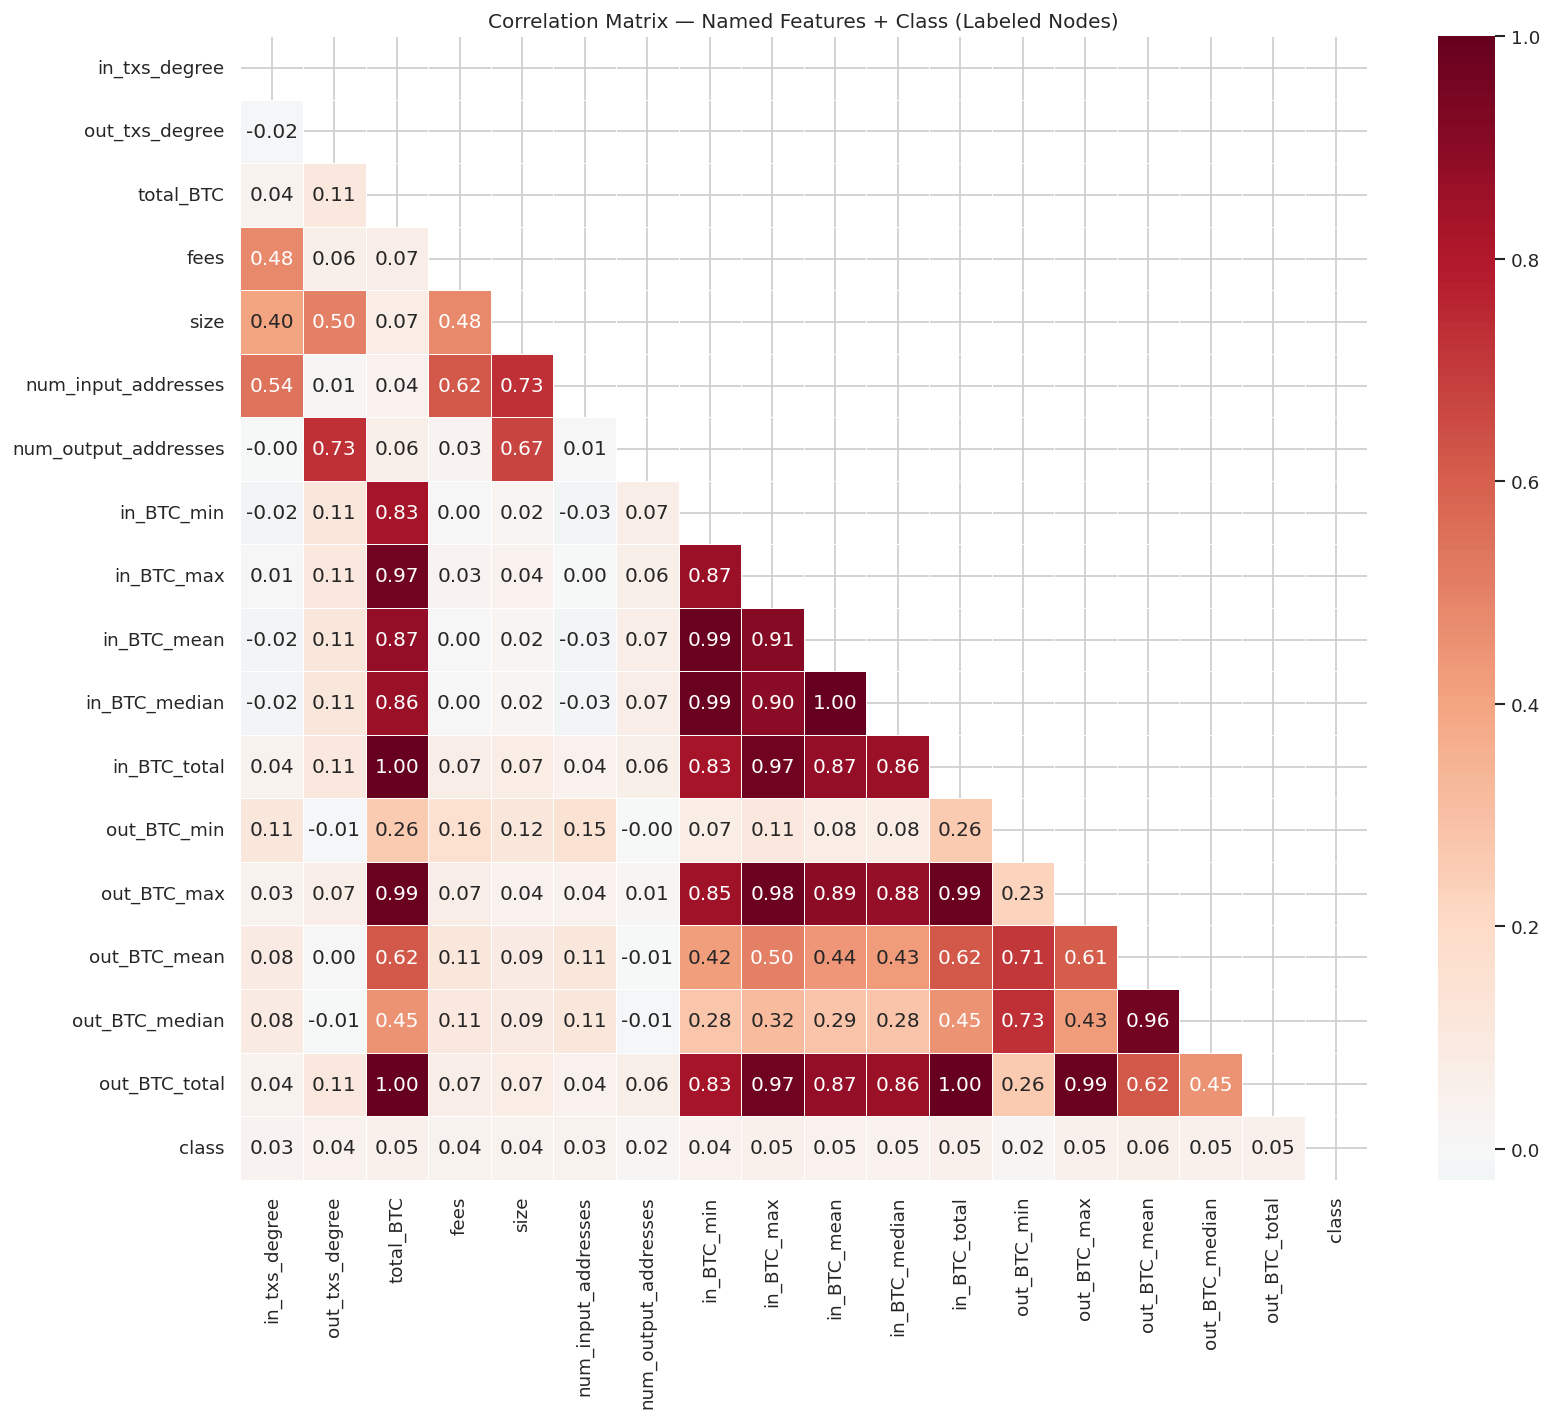

In [25]:
# Heatmap of named feature correlations
corr_matrix = labeled_merged[named_feats + ['class']].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Correlation Matrix — Named Features + Class (Labeled Nodes)')
plt.tight_layout()
plt.show()

## 7. Key EDA Takeaways

| Observation | Detail |
|---|---|
| **Class imbalance** | Among labeled nodes, ~9.8% are illicit and ~90.2% are licit (~9.2:1 ratio). This makes accuracy a poor metric — a trivial "always predict licit" classifier gets ~90% accuracy. Use F1 / AUC instead. |
| **Unlabeled nodes** | 77% of nodes have unknown labels, which limits supervised approaches but opens semi-supervised possibilities. |
| **Temporal structure** | 49 time steps ≈ bimonthly snapshots. Illicit fraction varies over time, suggesting time-based splits may be more realistic than random splits. |
| **Feature structure** | 166 features: 93 local (transaction-level) + 72 aggregated (neighborhood) + 1 time step + ~10 named Bitcoin-specific features. No missing values in the feature matrix. |
| **Degree distribution** | Heavy-tailed (power-law-like). Most nodes have very low degree; a few hubs have many connections. Mean total degree ≈ 2.3. |
| **Edge coverage** | Only ~14% of edges connect two labeled nodes — edge-feature-based models will discard unlabeled endpoints unless imputed. |